# Gated Recurrent Unit (GRU) — Character-Level Text Generation

A **GRU** (Gated Recurrent Unit) is a recurrent architecture closely related to the LSTM, but with fewer gates — a *reset* gate and an *update* gate, no separate cell state — which makes it lighter to train while still handling longer-range dependencies far better than a vanilla RNN. This notebook trains a small GRU-based character-level language model on Shakespeare's collected works: the network reads one character at a time and learns to predict the next one, which lets it generate new Shakespeare-like text once trained.

In [1]:
import os
import re
import unidecode
import string
import random

import urllib.request
import torch
import torch.nn as nn
from torch.autograd import Variable

## Data

The next cells download Shakespeare's text (skipping the download if it's already present locally), fix the hyperparameters used throughout the notebook, and load the raw text into memory. Two more building blocks are prepared here:
- `random_chunck`, which samples a random contiguous slice of the text of length `chunck_len` — training works on these fixed-length chunks rather than the full text at once.
- `vocab`, the set of unique characters actually present in this text (kept just as a sanity check). The model itself is sized over `string.printable` (`all_characters`/`n_characters`) rather than `vocab`, so it can represent any printable character, not only the ones that happen to occur in this particular text.

In [2]:
data_dir = "../data/SHAKESPEAR/"
file_path = os.path.join(data_dir, "shakespeare.txt")
url = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"

if not os.path.isfile(file_path):
    os.makedirs(data_dir, exist_ok=True)
    urllib.request.urlretrieve(url, file_path)
    print(f"Downloaded file to {file_path}")
else:
    print(f"File already exists at {file_path}, skipping download.")

File already exists at ../data/SHAKESPEAR/shakespeare.txt, skipping download.


In [3]:
chunck_len = 200
n_epochs= 2000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 1
lr = 0.005

In [4]:
all_characters = string.printable
n_characters = len(all_characters)

text = unidecode.unidecode(open(file_path, 'rb').read().decode(encoding='utf-8'))
text_len = len(text)
print(text_len)

1115394


In [5]:
def random_chunck(text: str, chunck_len: int):
    start_index = random.randint(0, text_len - chunck_len)
    end_index = start_index + chunck_len + 1
    return text[start_index : end_index]

In [6]:
vocab = sorted(set(text))
print(len(vocab))

65


## Model

`GRU` is a minimal character-level language model made of three pieces:
- `encoder` — an `nn.Embedding` mapping a character index to a `hidden_size`-dimensional vector.
- `gru` — an `nn.GRU` (`n_layers` layers) that updates the hidden state one character at a time.
- `decoder` — an `nn.Linear` projecting the GRU's output back to a distribution over the `n_characters` possible next characters.

`forward` takes a **single** character index and the current hidden state, and returns the predicted next-character distribution together with the updated hidden state — the surrounding training/generation loops are what step it forward one character at a time across a sequence.

In [7]:
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers = 4):
        super(GRU, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        self.encoder = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(input_size=hidden_size, hidden_size=hidden_size, num_layers=n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden):
        input = self.encoder(input.view(1, -1))
        output, hidden = self.gru(input.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        return output, hidden

    def init_hidden(self):
        return Variable(torch.zeros(self.n_layers, 1, self.hidden_size))

## Encoding & training utilities

- `char_tensor` turns a Python string into a `LongTensor` of character indices (positions in `all_characters`) — the format the embedding layer expects.
- `random_training_set` samples one random chunk of text and builds the `(input, target)` pair used for teacher forcing: `target` is `input` shifted by one character, so at every position the model learns to predict the very next character.
- The model, its `Adam` optimizer, and the loss (`CrossEntropyLoss`, appropriate since predicting the next character is a multi-class classification over `n_characters`) are instantiated last.

In [8]:
def char_tensor(string: str):
    tensor = torch.zeros(len(string)).long()
    for c in range(len(string)):
        tensor[c] = all_characters.index(string[c])

    return Variable(tensor)

In [9]:
def random_training_set(text:str):
    chunck = random_chunck(text, chunck_len)
    inp = char_tensor(chunck[: -1])
    target = char_tensor(chunck[1:])
    return inp, target

In [10]:
decoder = GRU(n_characters, hidden_size, n_characters, n_layers)
decode_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

## Training step

`train` runs one full pass over a `chunck_len`-character chunk: at each position it feeds the current character and hidden state through the GRU, accumulates the cross-entropy loss against the true next character, then backpropagates through the **whole chunk at once** (the per-character losses are summed before a single `.backward()`). It returns the average per-character loss for that chunk.

In [11]:
def train(inpt, target):
    hidden = decoder.init_hidden()
    decoder.zero_grad()
    loss = 0

    for c in range(chunck_len):
        output, hidden = decoder(inpt[c], hidden)
        loss += criterion(output, target[c].view(-1))

    loss.backward()
    decode_optimizer.step()

    return loss.item() / chunck_len

## Text generation (sampling)

`evaluate` generates text autoregressively from a seed string (`prime_str`): it first "warms up" the hidden state by feeding the priming characters through the network, then repeatedly samples the next character from the predicted distribution — scaled by `temperature` (lower is more conservative/repetitive, higher is more random) — and feeds that sampled character back in as the next input.

In [12]:
def evaluate(prime_str = 'A', predict_len = 100, temperature = 0.8):
    hidden = decoder.init_hidden()
    prime_input = char_tensor(prime_str)
    predicted = prime_str

    for p in range(len(prime_str) -1):
        _, hidden = decoder(prime_input[p], hidden)
    inp = prime_input[-1]

    for p in range(predict_len):
        output, hidden = decoder(inp, hidden)
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]

        predicted_char = all_characters[top_i]
        predicted += predicted_char
        inp = char_tensor(predicted_char)

    return predicted


## Run training

The main loop draws a fresh random chunk every epoch and trains on it. Every `print_every` epochs it prints a sample of generated text so progress can be inspected qualitatively; every `plot_every` epochs it records the *average* loss over that block of epochs into `all_losses` and resets the running `loss_avg` — this periodic averaging is what keeps the loss curve plotted below readable rather than jumping around on every single epoch.

In [13]:
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    inp, target = random_training_set(text)
    loss = train(inp, target)
    loss_avg += loss

    if epoch % print_every == 0:
        print('Epoch: %d (%d%%) \t Loss: %.4f' % (epoch, epoch / n_epochs * 100, loss))
        
    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

Epoch: 100 (5%) 	 Loss: 2.3056
Epoch: 200 (10%) 	 Loss: 2.3390
Epoch: 300 (15%) 	 Loss: 2.0095
Epoch: 400 (20%) 	 Loss: 2.1182
Epoch: 500 (25%) 	 Loss: 1.8785
Epoch: 600 (30%) 	 Loss: 2.0519
Epoch: 700 (35%) 	 Loss: 1.9334
Epoch: 800 (40%) 	 Loss: 1.8122
Epoch: 900 (45%) 	 Loss: 1.8848
Epoch: 1000 (50%) 	 Loss: 1.8771
Epoch: 1100 (55%) 	 Loss: 1.7762
Epoch: 1200 (60%) 	 Loss: 1.9263
Epoch: 1300 (65%) 	 Loss: 1.7205
Epoch: 1400 (70%) 	 Loss: 1.5923
Epoch: 1500 (75%) 	 Loss: 1.7194
Epoch: 1600 (80%) 	 Loss: 1.8070
Epoch: 1700 (85%) 	 Loss: 1.6024
Epoch: 1800 (90%) 	 Loss: 2.3558
Epoch: 1900 (95%) 	 Loss: 2.0911
Epoch: 2000 (100%) 	 Loss: 1.9750


## Results

The plot below shows the smoothed training loss (averaged over every `plot_every`-epoch block); it should trend downward as the model gets better at predicting Shakespeare's next character. Below that, a longer generated sample shows the model's output qualitatively once training is done.

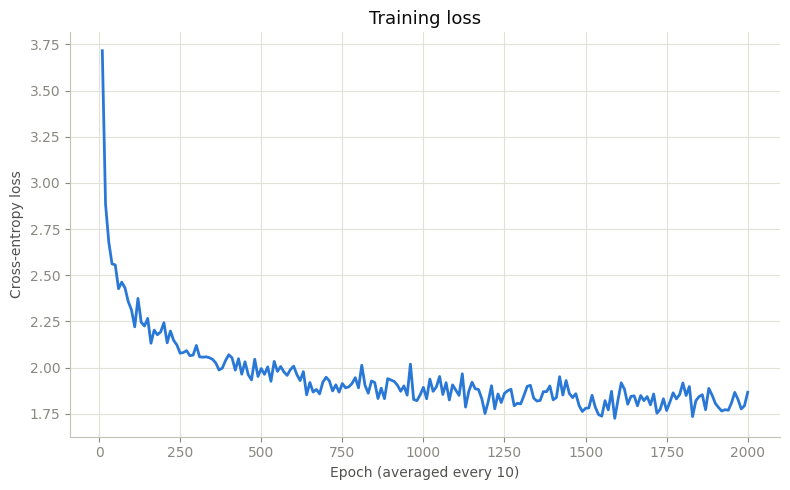

In [14]:
import matplotlib.pyplot as plt

epochs_axis = [i * plot_every for i in range(1, len(all_losses) + 1)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_axis, all_losses, color="#2a78d6", linewidth=2)

ax.set_title("Training loss", fontsize=13, color="#0b0b0b")
ax.set_xlabel(f"Epoch (averaged every {plot_every})", color="#52514e")
ax.set_ylabel("Cross-entropy loss", color="#52514e")

ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#898781")

plt.tight_layout()
plt.show()

In [15]:
print(evaluate('Th', 200, temperature=0.8))

There tear from their,
He but he dand and at me.

MRIANDY:
My so misclee you hand ao the mear:
To wouds an gore the wride of I man as with and good
My mastar, them; fone of am have bold my lord.

BRANDA


In [16]:
print(evaluate('Th', 200, temperature=1.4))

ThRANDO:
HEN go be us clonful when arge misdewINlelain; ene wart?
Marike of mine ageoshoon me I have kimne af; ivy? Be and dunes
Sweth? wine mighoul Maday-nor hatine affelf makely enevencens; be daugh M
